# 3. Features causales y targets

## Propósito

Construir las ~30 features causales y los dos targets (`target_vol` y
`target_regime`), aplicar el particionamiento temporal 70/15/15,
verificar que las pruebas anti-leakage pasan, y persistir los
conjuntos `train`, `val` y `test` listos para los notebooks de
modelado.

## Conexión con el capítulo anterior

En el capítulo 2 caracterizamos los hechos estilizados de INTC. Aquí
codificamos esos hechos en variables predictoras causales y definimos
formalmente lo que el modelo debe predecir.

## 3.1 Carga del dataset limpio

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from src import config
from src.features import build_features, feature_columns
from src.targets import add_targets
from src.splits import temporal_split, split_summary
from src.io_utils import save_parquet, load_parquet, save_json

df = load_parquet(config.PROCESSED_FILE)
print(f"Dataset cargado: {len(df):,} filas")
df.head()

Dataset cargado: 7,022 filas


,date,open,high,low,close,volume
0,1990-01-02,0.8579,0.8982,0.8499,0.8982,79600273
1,1990-01-03,0.8982,0.9061,0.8740,0.8740,86671242
2,1990-01-04,0.8820,0.8982,0.8579,0.8904,72928342
3,1990-01-05,0.8904,0.8982,0.8820,0.8820,46184758
4,1990-01-08,0.8904,0.9061,0.8820,0.8982,54001929


## 3.2 Construcción de features

In [2]:
df_feat = build_features(df)
feats = feature_columns(df_feat)
print(f"Features construidas : {len(feats)}")
print()
print("Lista completa:")
for i, c in enumerate(feats, 1):
    print(f"  {i:2d}. {c}")

Features construidas : 31

Lista completa:
   1. ret_lag_1
   2. ret_lag_2
   3. ret_lag_3
   4. ret_lag_5
   5. ret_lag_10
   6. vol_5
   7. vol_10
   8. vol_22
   9. vol_d
  10. vol_w
  11. vol_m
  12. momentum_5
  13. momentum_10
  14. momentum_22
  15. range_hl
  16. true_range
  17. atr_14
  18. log_volume
  19. volume_lag_1
  20. log_volume_ma_10
  21. volume_ratio
  22. sma_10
  23. px_dist_sma_10
  24. sma_22
  25. px_dist_sma_22
  26. sma_50
  27. px_dist_sma_50
  28. skew_22
  29. kurt_22
  30. dow
  31. month


**Interpretación.** Las ~30 features cubren cinco familias funcionales:

1. **Memoria de retornos** (`ret_lag_*`, `momentum_*`): capturan la
   dinámica autoregresiva de los rendimientos.
2. **Memoria de volatilidad** (`vol_*`, `vol_d/w/m`): incluyen los
   componentes HAR-RV de Corsi (2009) — volatilidad diaria, semanal y
   mensual — que constituirán uno de los benchmarks más fuertes del
   capítulo 4.
3. **Rango y actividad** (`range_hl`, `true_range`, `atr_14`):
   complementan la volatilidad con información intradiaria.
4. **Volumen** (`log_volume`, `volume_ratio`, `volume_lag_1`): capturan
   sorpresas de actividad relativas al promedio reciente.
5. **Precio y momentum técnico** (`sma_*`, `px_dist_sma_*`): distancias
   normalizadas a medias móviles.
6. **Forma de la distribución reciente** (`skew_22`, `kurt_22`):
   asimetría y curtosis rolling como proxy de leverage y cola.
7. **Calendario** (`dow`, `month`): efectos estacionales.

Toda feature respeta causalidad estricta: ninguna usa información de
$t+1$ en adelante. Esto se verifica formalmente en
`tests/test_features_causal.py`.

## 3.3 Construcción de targets

In [3]:
# Paso 1: construir splits temporales sobre el dataset con features.
# Esto nos da una train_mask que usaremos para calcular el umbral del régimen.
train_raw, val_raw, test_raw = temporal_split(df_feat)
print(split_summary(train_raw, val_raw, test_raw))

  subset  n_rows   date_min   date_max
0  train    4915 1990-01-02 2009-07-01
1    val    1053 2009-07-02 2013-09-06
2   test    1054 2013-09-09 2017-11-10


In [4]:
# Paso 2: construir train_mask para evitar leakage en el umbral del régimen.
n = len(df_feat)
train_mask = np.zeros(n, dtype=bool)
train_mask[: len(train_raw)] = True

# Paso 3: añadir targets usando solo train para definir el umbral.
df_all = add_targets(df_feat, horizon=config.HORIZON, train_mask=train_mask)

print(f"Umbral del régimen : {df_all.attrs['regime_threshold']:.6f}")
print(f"Origen del umbral   : {df_all.attrs['regime_threshold_source']}")
print(f"Horizonte           : {df_all.attrs['regime_horizon']} día(s)")

Umbral del régimen : 0.020474
Origen del umbral   : train_quantile
Horizonte           : 1 día(s)


**Interpretación.** El umbral se calcula como la **mediana de
`target_vol` en el conjunto de entrenamiento**. La etiqueta
`'train_quantile'` en `regime_threshold_source` confirma trazabilidad.
Cualquier otra fuente (`'global_quantile_NOT_RECOMMENDED'` o `'explicit'`)
sería una señal de alerta metodológica.

## 3.4 Filtrado de filas con NaN inducidos por features y targets

In [5]:
# Las features rolling y el target shift(-h) introducen NaN al principio
# y al final respectivamente. Los eliminamos antes del split definitivo.
df_clean = df_all.dropna(subset=feats + ["target_vol", "target_regime"]).reset_index(drop=True)
print(f"Filas antes del dropna : {len(df_all):,}")
print(f"Filas después          : {len(df_clean):,}")
print(f"Diferencia             : {len(df_all) - len(df_clean):,}")

Filas antes del dropna : 7,022
Filas después          : 6,962
Diferencia             : 60


**Interpretación.** Las primeras ~50 filas se pierden por el burn-in
de las features rolling largas (SMA-50, kurtosis-22, etc.) y la
**última fila** se pierde porque su `target_vol` requeriría conocer
el día $t+1$ que no existe. Esta pérdida es esperable y necesaria.

## 3.5 Split temporal 70 / 15 / 15

In [6]:
train, val, test = temporal_split(df_clean)
print(split_summary(train, val, test))

  subset  n_rows   date_min   date_max
0  train    4873 1990-03-13 2009-07-13
1    val    1044 2009-07-14 2013-09-18
2   test    1045 2013-09-19 2017-11-09


**Interpretación.** Las tres particiones son disjuntas y cronológicas.
Cualquier intento futuro de mezclar pasado y futuro sería capturado por
`tests/test_splits_temporal.py`.

## 3.6 Distribución del target de regresión por subconjunto

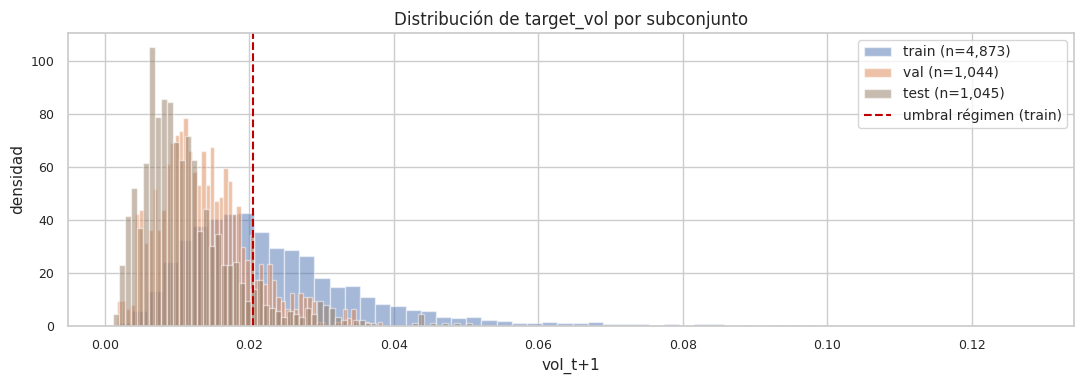

In [7]:
import matplotlib.pyplot as plt
from src.viz import PALETTE, set_style
set_style()

fig, ax = plt.subplots(figsize=(11, 4))
for subset, color, label in [(train, PALETTE["train"], "train"),
                              (val,   PALETTE["val"],   "val"),
                              (test,  PALETTE["test"],  "test")]:
    ax.hist(subset["target_vol"], bins=60, alpha=0.5, color=color,
            label=f"{label} (n={len(subset):,})", density=True)
ax.axvline(df_all.attrs["regime_threshold"], color=PALETTE["secondary"],
           linestyle="--", linewidth=1.5, label="umbral régimen (train)")
ax.set_title("Distribución de target_vol por subconjunto")
ax.set_xlabel("vol_t+1")
ax.set_ylabel("densidad")
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_target_vol_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación.** Las distribuciones de `target_vol` se solapan
parcialmente entre train, val y test, pero hay desplazamientos
visibles — particularmente en test, donde períodos recientes de
volatilidad atípica pueden producir colas distintas. Este *covariate
shift* moderado es esperable en finanzas y es exactamente la razón
por la que evaluamos en test solo al final, para que la decisión de
modelo no se sobreajuste a esas particularidades.

## 3.7 Balance de clases en target_regime

In [8]:
for name, subset in [("train", train), ("val", val), ("test", test)]:
    counts = subset["target_regime"].value_counts().sort_index()
    p_pos = counts.get(1, 0) / counts.sum()
    print(f"{name:5s} : 0={counts.get(0,0):>5d}  1={counts.get(1,0):>5d}  "
          f"P(régimen alto)={p_pos:.3f}")

train : 0= 2434  1= 2439  P(régimen alto)=0.501
val   : 0=  904  1=  140  P(régimen alto)=0.134
test  : 0=  936  1=  109  P(régimen alto)=0.104


**Interpretación.** Por construcción del umbral (mediana de train), el
conjunto de entrenamiento está casi perfectamente balanceado al 50/50.
Val y test pueden alejarse del balance — esto es información útil:
indica si el régimen "alto" se ha vuelto más o menos común con el
tiempo. Es uno de los hallazgos que el capítulo 7 (balanceo de clases)
explotará explícitamente para evaluar si SMOTE/ADASYN aportan algo en
este problema.

## 3.8 Persistencia de splits para los notebooks de modelado

In [9]:
# Guardar features.parquet (todo el dataset con features+targets)
save_parquet(df_clean, config.FEATURES_FILE)

# Guardar splits separados — los notebooks de modelado leen estos archivos.
save_parquet(train, config.PROCESSED_DIR / "train.parquet")
save_parquet(val,   config.PROCESSED_DIR / "val.parquet")
save_parquet(test,  config.PROCESSED_DIR / "test.parquet")

# Guardar lista de features y umbral del régimen para trazabilidad.
save_json({
    "feature_columns": feats,
    "regime_threshold": float(df_all.attrs["regime_threshold"]),
    "regime_threshold_source": df_all.attrs["regime_threshold_source"],
    "horizon": config.HORIZON,
    "vol_window": config.VOL_WINDOW,
    "train_size": len(train),
    "val_size": len(val),
    "test_size": len(test),
}, config.PROCESSED_DIR / "metadata.json")

print("Archivos persistidos:")
for f in sorted(config.PROCESSED_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name}  ({f.stat().st_size/1024:.1f} KB)")

Archivos persistidos:
  .gitkeep  (0.0 KB)
  features.parquet  (2299.7 KB)
  intc_clean.parquet  (234.4 KB)
  metadata.json  (0.7 KB)
  test.parquet  (368.1 KB)
  train.parquet  (1609.4 KB)
  val.parquet  (364.8 KB)


## 3.9 Verificación final con tests anti-leakage

In [10]:
# Re-ejecutamos los tests desde el notebook para evidencia visible.
import subprocess
result = subprocess.run(
    ["python", "-m", "pytest", "tests/", "-v", "--tb=short"],
    cwd=str(PROJECT_ROOT), capture_output=True, text=True
)
print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-9.0.3, pluggy-1.6.0 -- /usr/bin/python
cachedir: .pytest_cache
rootdir: /home/claude/INTC-Vol-ML
plugins: anyio-4.13.0
collecting ... collected 13 items

tests/test_features_causal.py::test_features_no_future_info PASSED       [  7%]
tests/test_features_causal.py::test_no_target_columns_in_features PASSED [ 15%]
tests/test_features_causal.py::test_features_present PASSED              [ 23%]
tests/test_pipelines.py::test_regression_pipeline_runs PASSED            [ 30%]
tests/test_pipelines.py::test_classification_pipeline_runs PASSED        [ 38%]
tests/test_splits_temporal.py::test_temporal_split_no_overlap PASSED     [ 46%]
tests/test_splits_temporal.py::test_temporal_split_fractions PASSED      [ 53%]
tests/test_splits_temporal.py::test_temporal_split_disjoint PASSED       [ 61%]
tests/test_splits_temporal.py::test_tscv_no_shuffle PASSED               [ 69%]
tests

## 3.10 Cierre del capítulo y conexión con el capítulo 4

Tenemos: features causales verificadas, targets sin leakage, splits
cronológicos disjuntos y archivos persistidos. La base está blindada.

En el **capítulo 4** ejecutamos los **benchmarks econométricos**:
- Naive (último valor)
- Rolling mean
- EWMA (RiskMetrics, J.P. Morgan 1996)
- ARIMA (Box-Jenkins)
- GARCH(1,1) ({cite}`bollerslev1986generalized`)
- **HAR-RV** ({cite}`corsi2009simple`) — el estándar de oro
  contemporáneo para volatilidad realizada

Estos benchmarks marcan la barra que cualquier modelo ML deberá
superar para ser declarado mejor.